In [ ]:
!pip install nltk scikit-learn pandas matplotlib wordcloud tqdm


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=["target", "id", "date", "flag", "user", "text"]
)

df.head()


,target,id,date,flag,user,text
0,0,1.467810e+09,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1.467811e+09,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1.467811e+09,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1.467811e+09,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1.467811e+09,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df["sentiment"] = df["target"].map({0: "negative", 4: "positive"})
df = df[["text", "sentiment"]]
df.head()


,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",negative
1,is upset that he can't update his Facebook by ...,negative
2,@Kenichan I dived many times for the ball. Man...,negative
3,my whole body feels itchy and like its on fire,negative
4,"@nationwideclass no, it's not behaving at all....",negative


In [ ]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#[A-Za-z0-9_]+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text


In [ ]:
tqdm.pandas()
df["clean_text"] = df["text"].progress_apply(clean_text)
df.head()


100%|██████████| 21124/21124 [00:00<00:00, 102432.44it/s]


,text,sentiment,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",negative,awww thats bummer shoulda got david carr third...
1,is upset that he can't update his Facebook by ...,negative,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,negative,dived many times ball managed save rest go bounds
3,my whole body feels itchy and like its on fire,negative,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",negative,behaving im mad cant see


In [ ]:
print("Total rows:", len(df))

sample_size = min(100000, len(df))
print("Sampling:", sample_size)

sample_df = df.sample(sample_size, random_state=42)

X = sample_df["clean_text"]
y = sample_df["sentiment"]


Total rows: 21124
Sampling: 21124


In [ ]:
print("Total rows:", len(df))

sample_size = min(100000, len(df))
print("Sampling:", sample_size)

sample_df = df.sample(sample_size, random_state=42)


Total rows: 21124
Sampling: 21124


In [ ]:
X = sample_df["clean_text"]
y = sample_df["sentiment"]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 16899
Test size: 4225


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
df["sentiment"].value_counts()


,count
sentiment,
negative,21124


In [ ]:
df.head()


,text,sentiment,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",negative,awww thats bummer shoulda got david carr third...
1,is upset that he can't update his Facebook by ...,negative,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,negative,dived many times ball managed save rest go bounds
3,my whole body feels itchy and like its on fire,negative,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",negative,behaving im mad cant see


In [ ]:
df.columns


Index(['text', 'sentiment', 'clean_text'], dtype='object')

In [ ]:
vectorizer = TfidfVectorizer(max_features=20000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)


In [ ]:
print(np.unique(y_train, return_counts=True))


(array(['negative'], dtype=object), array([16899]))


In [ ]:
print(df.columns)


Index(['text', 'sentiment', 'clean_text'], dtype='object')


In [ ]:
# --- ALL-IN-ONE: Load, preprocess, vectorize, split, train Logistic Regression ---

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1️⃣ Load Sentiment140 dataset (adjust path if needed)
# Make sure the CSV is downloaded locally
df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)

# 2️⃣ Assign correct column names
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

# 3️⃣ Map target to human-readable labels
df['label'] = df['target'].replace({0: 'negative', 2: 'neutral', 4: 'positive'})

# 4️⃣ Optional: remove neutral tweets for binary classification
df = df[df['label'] != 'neutral']

# 5️⃣ Split features and labels
X = df['text']
y = df['label']

# 6️⃣ Train/test split with stratification to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

# 7️⃣ Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 8️⃣ Train Logistic Regression
model = LogisticRegression(max_iter=200)
model.fit(X_train_tfidf, y_train)

# 9️⃣ Optional: print training info
print("Training complete!")
print("Classes:", model.classes_)
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


Training complete!
Classes: ['negative' 'positive']
Train shape: (1280000, 5000)
Test shape: (320000, 5000)


In [ ]:


y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.80      0.78      0.79    160000
    positive       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



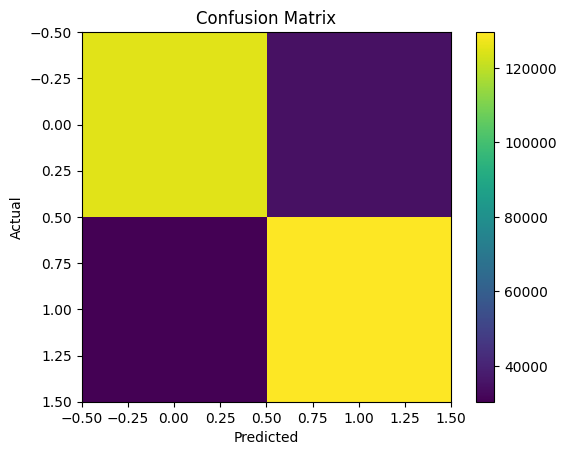

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


In [ ]:
df['label'].value_counts()


,count
label,
negative,800000
positive,800000


In [ ]:
# Create sentiment column safely

if "label" in df.columns:
    # If label contains strings like 'positive'/'negative'
    if df["label"].dtype == object:
        df["sentiment"] = df["label"]
    else:
        # If label has 0/4, convert to text
        df["sentiment"] = df["label"].map({0: "negative", 4: "positive"})
else:
    # fallback to target column (0/4)
    df["sentiment"] = df["target"].map({0: "negative", 4: "positive"})

print(df["sentiment"].value_counts())


sentiment
negative    800000
positive    800000
Name: count, dtype: int64


Cleaning texts: 100%|██████████| 1600000/1600000 [00:26<00:00, 61525.85it/s]


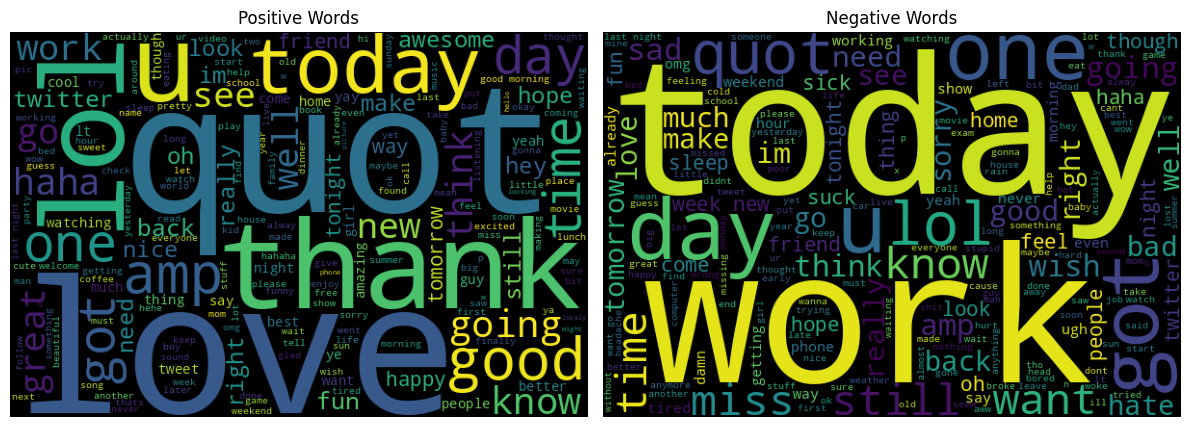

100%|██████████| 32/32 [00:25<00:00,  1.23it/s]


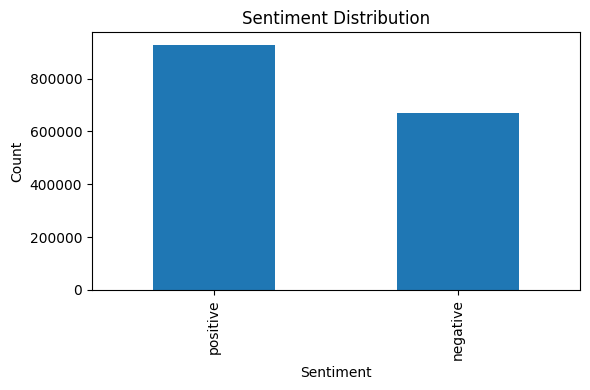

Done.


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from tqdm import tqdm

DF_NAME = "df"
CLEAN_COL = "clean_text"
PRED_COL = "predicted_sentiment"
WC_SAMPLE = 50000
PRED_BATCH = 50000

try:
    df = globals()[DF_NAME]
except KeyError:
    raise RuntimeError("DataFrame 'df' not found.")

if CLEAN_COL not in df.columns:
    import nltk
    try:
        from nltk.corpus import stopwords
        nltk.download('stopwords', quiet=True)
        stop_words = set(stopwords.words('english'))
    except Exception:
        stop_words = set(["the","and","is","in","to","of","a","for","it","on","that","this"])
    def simple_clean(text):
        text = str(text).lower()
        text = re.sub(r"http\S+|www\.\S+", "", text)
        text = re.sub(r"@\w+", "", text)
        text = re.sub(r"#[A-Za-z0-9_]+", "", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        text = " ".join([w for w in text.split() if w not in stop_words])
        return text
    tqdm.pandas(desc="Cleaning texts")
    df[CLEAN_COL] = df["text"].progress_apply(simple_clean)

if "sentiment" not in df.columns:
    if "label" in df.columns:
        df["sentiment"] = df["label"].map({0:"negative",4:"positive"}) if df["label"].dtype != object else df["label"]
    elif "target" in df.columns:
        df["sentiment"] = df["target"].map({0:"negative",4:"positive"})
    else:
        df["sentiment"] = None

pos_count = len(df[df["sentiment"] == "positive"])
neg_count = len(df[df["sentiment"] == "negative"])

def safe_sample_join(df_subset, n):
    if len(df_subset) == 0:
        return ""
    n_use = min(n, len(df_subset))
    try:
        text = " ".join(df_subset[CLEAN_COL].sample(n_use, random_state=42).astype(str).tolist())
    except Exception:
        text = " ".join(df_subset[CLEAN_COL].astype(str).tolist())
    return text

if pos_count > 0:
    positive_text = safe_sample_join(df[df["sentiment"]=="positive"], WC_SAMPLE)
else:
    positive_text = ""
if neg_count > 0:
    negative_text = safe_sample_join(df[df["sentiment"]=="negative"], WC_SAMPLE)
else:
    negative_text = ""

plt.figure(figsize=(12,5))
if positive_text:
    plt.subplot(1,2,1)
    plt.title("Positive Words")
    plt.imshow(WordCloud(width=600, height=400).generate(positive_text))
    plt.axis("off")
else:
    plt.subplot(1,2,1)
    plt.text(0.5,0.5,"No positive samples", ha="center")
    plt.axis("off")

if negative_text:
    plt.subplot(1,2,2)
    plt.title("Negative Words")
    plt.imshow(WordCloud(width=600, height=400).generate(negative_text))
    plt.axis("off")
else:
    plt.subplot(1,2,2)
    plt.text(0.5,0.5,"No negative samples", ha="center")
    plt.axis("off")

plt.tight_layout()
plt.show()

if 'vectorizer' not in globals() or 'model' not in globals():
    raise RuntimeError("Missing 'vectorizer' or 'model'.")

vectorizer = globals()['vectorizer']
model = globals()['model']

texts = df[CLEAN_COL].astype(str)
n_rows = len(texts)
preds = []

for start in tqdm(range(0, n_rows, PRED_BATCH)):
    end = min(start + PRED_BATCH, n_rows)
    batch_texts = texts.iloc[start:end].tolist()
    X_batch = vectorizer.transform(batch_texts)
    batch_preds = model.predict(X_batch)
    preds.extend(batch_preds)

df[PRED_COL] = preds

out_name = "sentiment_predictions.csv"
df.to_csv(out_name, index=False)

try:
    dist = df[PRED_COL].value_counts()
    plt.figure(figsize=(6,4))
    dist.plot(kind="bar")
    plt.title("Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plot error:", str(e))

print("Done.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 1600000/1600000 [00:17<00:00, 92449.45it/s]


              precision    recall  f1-score   support

    negative       0.77      0.75      0.76      9989
    positive       0.75      0.78      0.77     10011

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



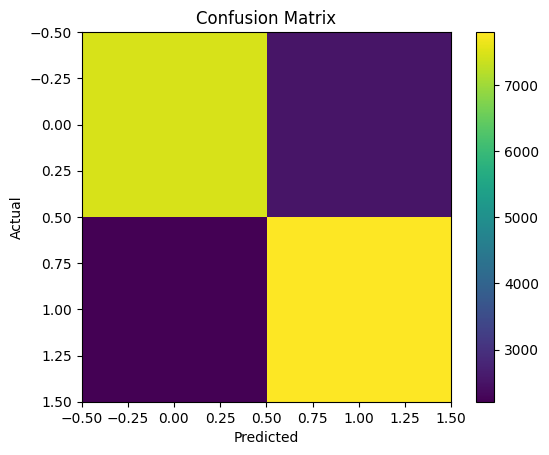

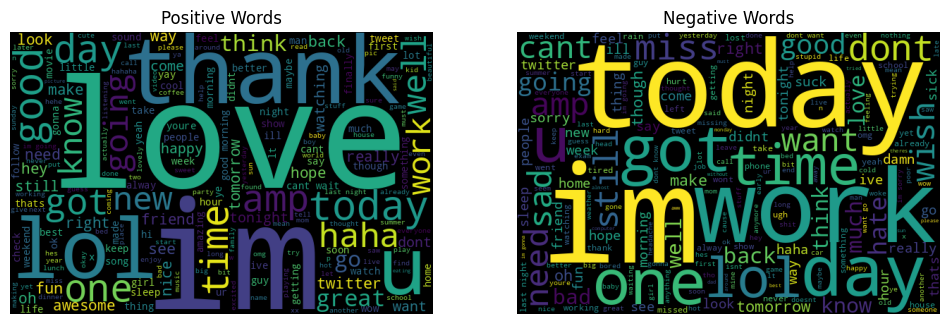

100%|██████████| 32/32 [00:16<00:00,  1.92it/s]


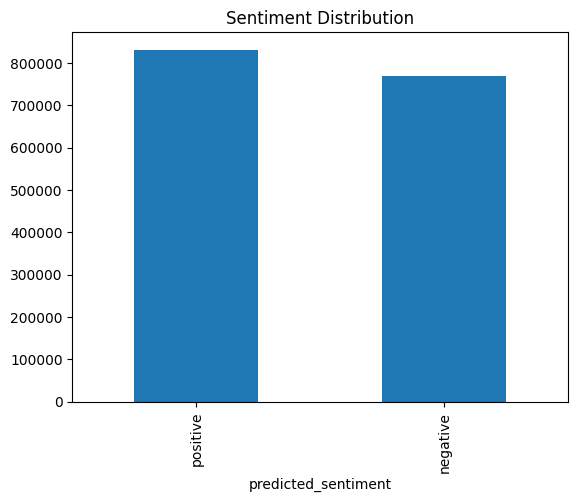

In [ ]:
!pip install nltk scikit-learn pandas matplotlib wordcloud tqdm

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

df = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=["target", "id", "date", "flag", "user", "text"]
)

df["sentiment"] = df["target"].map({0: "negative", 4: "positive"})
df = df[["text", "sentiment"]]

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#[A-Za-z0-9_]+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

tqdm.pandas()
df["clean_text"] = df["text"].progress_apply(clean_text)

sample_size = min(100000, len(df))
sample_df = df.sample(sample_size, random_state=42)

X = sample_df["clean_text"]
y = sample_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(max_features=20000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=200)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

def safe_sample_join(df_subset, n):
    n = min(n, len(df_subset))
    return " ".join(df_subset.sample(n, random_state=42)["clean_text"].tolist())

positive_text = safe_sample_join(df[df["sentiment"]=="positive"], 50000)
negative_text = safe_sample_join(df[df["sentiment"]=="negative"], 50000)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Positive Words")
plt.imshow(WordCloud(width=600, height=400).generate(positive_text))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Negative Words")
plt.imshow(WordCloud(width=600, height=400).generate(negative_text))
plt.axis("off")

plt.show()

batch_size = 50000
predictions = []
clean_texts = df["clean_text"].tolist()

for i in tqdm(range(0, len(clean_texts), batch_size)):
    batch = clean_texts[i:i+batch_size]
    batch_tfidf = vectorizer.transform(batch)
    preds = model.predict(batch_tfidf)
    predictions.extend(preds)

df["predicted_sentiment"] = predictions

df.to_csv("sentiment_predictions.csv", index=False)

df["predicted_sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()
